In [34]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32

In [35]:
# Вычисление числа Пи методом Монте-Карло на CPU
def monte_carlo_cpu(N):
    count = 0
    for _ in range(N):
        x, y = np.random.random(), np.random.random()
        if x*x + y*y <= 1.0:
            count += 1
    return 4.0 * count / N

In [36]:
# CUDA ядро для вычисления числа Пи методом Монте-Карло
@cuda.jit
def monte_carlo_gpu_kernel(N, results, rng_states):
    idx = cuda.grid(1)
    if idx < N:
        # Генерация случайных чисел на GPU с помощью CURAND
        x = xoroshiro128p_uniform_float32(rng_states, idx)
        y = xoroshiro128p_uniform_float32(rng_states, idx + N)

        # Проверка попадания в четверть круга
        if x*x + y*y <= 1.0:
            results[idx] = 1
        else:
            results[idx] = 0

In [37]:
# Вычисление числа Пи методом Монте-Карло на GPU
def monte_carlo_gpu(N):

    # Создание состояний для CURAND
    rng_states = create_xoroshiro128p_states(N * 2, seed=int(time.time()))

    # Массив для результатов на GPU
    results = cuda.device_array(N, dtype=np.int32)

    # Настройка сетки
    threads_per_block = 256
    blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

    # Замер полного времени
    start = time.time()
    monte_carlo_gpu_kernel[blocks_per_grid, threads_per_block](N, results, rng_states)
    cuda.synchronize()
    elapsed = time.time() - start

    # Подсчет попаданий
    inside_circle = results.copy_to_host().sum()
    pi_estimate = 4.0 * inside_circle / N

    return pi_estimate, elapsed

In [41]:
# Количество точек для тестирования
Ns = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

# Списки для хранения результатов
cpu_times = []
gpu_times = []
pi_cpu_vals = []
pi_gpu_vals = []

for N in Ns:
    print(f"\nОбработка N = {N} точек...")

    # CPU эксперимент
    start_cpu = time.time()
    pi_cpu = monte_carlo_cpu(N)
    time_cpu = time.time() - start_cpu

    # GPU эксперимент
    pi_gpu, time_gpu = monte_carlo_gpu(N)

    cpu_times.append(time_cpu)
    gpu_times.append(time_gpu)
    pi_cpu_vals.append(pi_cpu)
    pi_gpu_vals.append(pi_gpu)

    speedup = time_cpu / time_gpu if time_gpu > 0 else 0
    print(f"  CPU: π = {pi_cpu:.6f}, время = {time_cpu:.6f} сек")
    print(f"  GPU: π = {pi_gpu:.6f}, время = {time_gpu:.6f} сек")
    print(f"  Ускорение: {speedup:.2f}x")

speedups = [cpu / gpu for cpu, gpu in zip(cpu_times, gpu_times)]

results_df = pd.DataFrame({
    'Число точек (N)': Ns,
    'Pi (CPU)': pi_cpu_vals,
    'Время CPU (сек)': cpu_times,
    'Pi (GPU)': pi_gpu_vals,
    'Время GPU (сек)': gpu_times,
    'Ускорение': speedups
})

print(results_df.to_string(index=False, float_format='%.6f'))


Обработка N = 1000 точек...
  CPU: π = 3.140000, время = 0.001452 сек
  GPU: π = 3.148000, время = 0.000430 сек
  Ускорение: 3.38x

Обработка N = 2000 точек...
  CPU: π = 3.118000, время = 0.003545 сек
  GPU: π = 3.192000, время = 0.000235 сек
  Ускорение: 15.06x

Обработка N = 3000 точек...
  CPU: π = 3.081333, время = 0.003283 сек
  GPU: π = 3.173333, время = 0.000271 сек
  Ускорение: 12.12x

Обработка N = 4000 точек...
  CPU: π = 3.110000, время = 0.004362 сек
  GPU: π = 3.148000, время = 0.000196 сек
  Ускорение: 22.26x

Обработка N = 5000 точек...
  CPU: π = 3.128800, время = 0.005302 сек
  GPU: π = 3.132000, время = 0.000190 сек
  Ускорение: 27.83x

Обработка N = 6000 точек...
  CPU: π = 3.132000, время = 0.006438 сек
  GPU: π = 3.144000, время = 0.000192 сек
  Ускорение: 33.50x

Обработка N = 7000 точек...
  CPU: π = 3.138857, время = 0.007387 сек
  GPU: π = 3.142286, время = 0.000195 сек
  Ускорение: 37.97x

Обработка N = 8000 точек...
  CPU: π = 3.158500, время = 0.008489 сек

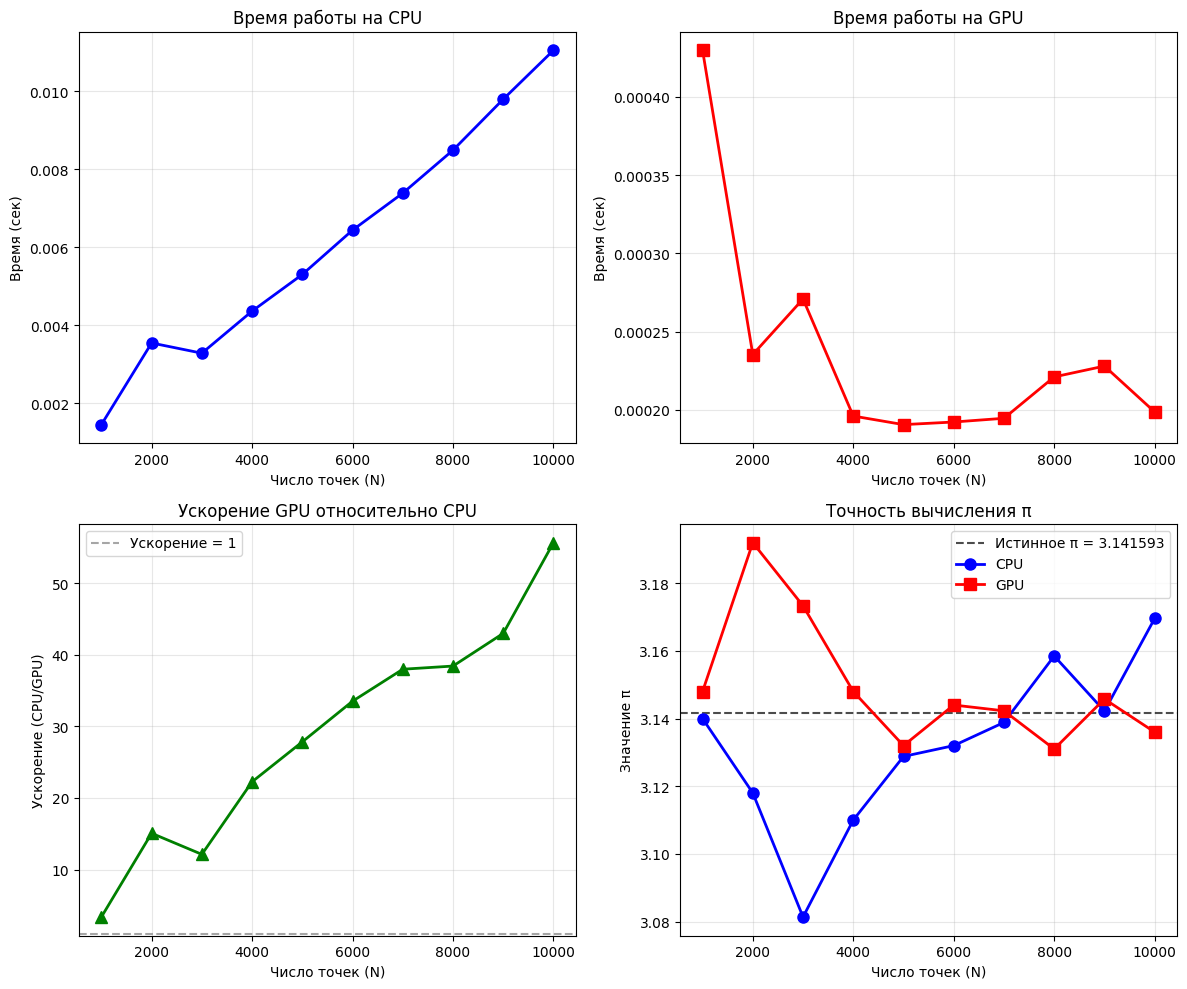

In [42]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# График 1: Время работы CPU
axs[0, 0].plot(Ns, cpu_times, marker='o', color='b', linewidth=2, markersize=8)
axs[0, 0].set_xlabel('Число точек (N)')
axs[0, 0].set_ylabel('Время (сек)')
axs[0, 0].set_title('Время работы на CPU')
axs[0, 0].grid(True, alpha=0.3)

# График 2: Время работы GPU
axs[0, 1].plot(Ns, gpu_times, marker='s', color='r', linewidth=2, markersize=8)
axs[0, 1].set_xlabel('Число точек (N)')
axs[0, 1].set_ylabel('Время (сек)')
axs[0, 1].set_title('Время работы на GPU')
axs[0, 1].grid(True, alpha=0.3)

# График 3: Ускорение
axs[1, 0].plot(Ns, speedups, marker='^', color='g', linewidth=2, markersize=8)
axs[1, 0].axhline(y=1, color='gray', linestyle='--', alpha=0.7, label='Ускорение = 1')
axs[1, 0].set_xlabel('Число точек (N)')
axs[1, 0].set_ylabel('Ускорение (CPU/GPU)')
axs[1, 0].set_title('Ускорение GPU относительно CPU')
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend()

# График 4: Точность вычислений
axs[1, 1].axhline(y=np.pi, color='black', linestyle='--', alpha=0.7, label=f'Истинное π = {np.pi:.6f}')
axs[1, 1].plot(Ns, pi_cpu_vals, marker='o', color='b', linewidth=2, markersize=8, label='CPU')
axs[1, 1].plot(Ns, pi_gpu_vals, marker='s', color='r', linewidth=2, markersize=8, label='GPU')
axs[1, 1].set_xlabel('Число точек (N)')
axs[1, 1].set_ylabel('Значение π')
axs[1, 1].set_title('Точность вычисления π')
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].legend()

plt.tight_layout()
plt.show()